# M146 Final Project



In [1]:


%pip install -q -U datasets transformers accelerate sentence-transformers scikit-learn matplotlib peft trl bitsandbytes


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [2]:

import os
import re
import gc
import json
import math
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("m146_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Device:", DEVICE)


Device: cuda


In [3]:
def clear_memory(*names):
    """Delete large variables by name and clear Python/CUDA memory."""
    for name in names:
        if name in globals():
            del globals()[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


## Part B: GSM8K Reasoning

The prompt below is intentionally minimal. You can add your own instructions above the final-answer rule.


In [4]:

SYSTEM_PROMPT = """
Your task is to solve the math problem.

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()


In [5]:

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from trl import SFTTrainer, SFTConfig

MATH_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
N_EVAL = 100

gsm8k = load_dataset("openai/gsm8k", "main")
gsm8k_test_100 = gsm8k["test"].select(range(N_EVAL))

def extract_boxed(text):
    idx = text.rfind("\\boxed{")
    if idx == -1:
        return None
    start = idx + len("\\boxed{")
    depth = 1
    pos = start
    while pos < len(text) and depth > 0:
        if text[pos] == "{":
            depth += 1
        elif text[pos] == "}":
            depth -= 1
        pos += 1
    if depth != 0:
        return None
    return text[start:pos - 1]


def extract_gt(raw_answer):
    match = re.search(r"####\s*(.+)", raw_answer)
    return match.group(1).strip().replace(",", "") if match else raw_answer.strip()


def extract_model_answer(text):
    boxed = extract_boxed(text)
    if boxed is not None:
        return boxed.strip()
    nums = re.findall(r"-?\d+(?:\.\d+)?", text)
    return nums[-1] if nums else ""


def normalize_answer(ans):
    s = str(ans).strip().replace(",", "").replace("$", "").replace("%", "").replace(" ", "")
    s = re.sub(r"\\text\{([^}]*)\}", r"\1", s)
    s = re.sub(r"\\(left|right|displaystyle)", "", s)
    s = re.sub(r"\\d?frac\{([^}]+)\}\{([^}]+)\}", r"\1/\2", s)
    try:
        v = float(s)
        if math.isfinite(v):
            return str(int(v)) if v == int(v) else str(v)
    except (ValueError, OverflowError):
        pass
    if "/" in s and s.count("/") == 1:
        try:
            a, b = s.split("/")
            return f"{float(a) / float(b):.10g}"
        except (ValueError, ZeroDivisionError):
            pass
    return s


def answers_match(pred, gt):
    p, g = normalize_answer(pred), normalize_answer(gt)
    if p == g:
        return True
    try:
        return abs(float(p) - float(g)) < 1e-6
    except (ValueError, TypeError):
        return False


def load_math_model(model_name=MATH_MODEL, lora_path=None):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    )
    if lora_path:
        model = PeftModel.from_pretrained(model, lora_path)
    model.eval()
    return model, tokenizer


def make_gsm_prompts(tokenizer, questions, system_prompt=SYSTEM_PROMPT, few_shot_messages=None):
    prompts = []
    for q in questions:
        messages = [{"role": "system", "content": system_prompt}]
        if few_shot_messages:
            messages.extend(few_shot_messages)
        messages.append({"role": "user", "content": q})
        prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))
    return prompts


def generate_math(model, tokenizer, questions, system_prompt=SYSTEM_PROMPT, few_shot_messages=None, batch_size=16, max_new_tokens=512):
    responses = []
    for start in range(0, len(questions), batch_size):
        batch_questions = questions[start:start + batch_size]
        prompts = make_gsm_prompts(tokenizer, batch_questions, system_prompt=system_prompt, few_shot_messages=few_shot_messages)
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)
        prompt_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            out = model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens)
        for i in range(len(batch_questions)):
            responses.append(tokenizer.decode(out[i][prompt_len:], skip_special_tokens=True).strip())
    return responses


def evaluate_gsm8k(model, tokenizer, split, num_samples=100, system_prompt=SYSTEM_PROMPT, few_shot_messages=None, batch_size=16, output_name=None):
    n = min(num_samples, len(split))
    records = []
    correct = 0
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        questions = [split[i]["question"] for i in range(start, end)]
        gts = [extract_gt(split[i]["answer"]) for i in range(start, end)]
        responses = generate_math(model, tokenizer, questions, system_prompt=system_prompt, few_shot_messages=few_shot_messages, batch_size=batch_size)
        for offset, (q, gt, resp) in enumerate(zip(questions, gts, responses)):
            pred = extract_model_answer(resp)
            ok = answers_match(pred, gt)
            correct += int(ok)
            records.append({
                "index": start + offset,
                "question": q,
                "ground_truth": gt,
                "model_response": resp,
                "extracted_answer": pred,
                "correct": ok,
            })
    result = {"accuracy": correct / n, "correct": correct, "total": n, "records": records}
    if output_name:
        path = OUTPUT_DIR / output_name
        path.write_text(json.dumps(result, indent=2))
    return result


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

### B.1-B.2 Base Model Evaluation


For B.1, load the base Qwen2.5-1.5B-Instruct model and evaluate it on the fixed 100 GSM8K test questions.

In [6]:
math_model, math_tokenizer = load_math_model()

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
b1 = evaluate_gsm8k(math_model, math_tokenizer, gsm8k_test_100, num_samples=100)
print(b1["accuracy"])

0.36


In [ ]:
wrong = [r for r in b1["records"] if not r["correct"]]


for r in wrong[:3]:
    print("==========================================================================")
    print("Q:", r["question"])
    print("------------------------------------------------------------")
    print("MODEL:", r["model_response"][-600:])
    print("------------------------------------------------------------")
    print("extracted:", r["extracted_answer"], "| ground truth:", r["ground_truth"])

Q: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
------------------------------------------------------------
MODEL: } = \$80,000 + \$50,000 = \$130,000 \]

### Step 2: New Value After Repairs
The problem states that the repairs increased the value of the house by 150%.

New value = Original value + (Original value * Percentage increase)
\[ \text{New value} = \$80,000 + (\$80,000 \times 0.15) \]
\[ \text{New value} = \$80,000 + \$12,000 = \$92,000 \]

### Step 3: Profit Calculation
Profit = New value - Total cost
\[ \text{Profit} = \$92,000 - \$130,000 = -\$27,000 \]

Since the result is negative, it means Josh incurred a loss rather than making a profit.

Therefore, the final answer is:
\[
\boxed{-27000}
\]
------------------------------------------------------------
extracted: -27000 | ground truth: 70000
Q: Every day, Wendi feeds each of her chicken

# Failure Modes:

Question 1: This is a reasoning error. The model simply misunderstood how to calculate profit here.

Question 2: This is a straight arithmitic error. The model caluclates 15 + 25 as 4 rather than 40. Furthermore, we have a reasoning error, as the final step was 56/20 which is an irrelevant step.

Question 3: Reasoning error/misunderstanding. The model failed to account for the fact that Carla needed to restart the download from the beginning, along with the extra 20 minutes that it took fro the computer to restart.

# B.3:

Here r is referes to the dimensionality of the ΔW matrix. Increasing LoRA rank (r) increases the number of entries in the ΔW matrix. In other words, increasing r leads to MORE CORRECTIONS, and decreasing leads ot a smaller matrix with less corrections.

Alpha is a sclaing factor, and controls how large the entries of ΔW are. Increasing α leands to larger entries and decreaing leads to smaller entries, which are thought of as the magnitude of the corrections.

The gradient accumulation hyperparameter controls how many questions the model goes through before updating it's weights. Increasing the grad accumulation would increase the amount of questions the model goes through before updating weights, which makes the updates more accurate, though there would be less updates overall. Decreasing allows for mor eupdates, though the updates are less accurate and more succuptible to noise.



In [7]:
from peft import LoraConfig, TaskType

LORA_DEFAULTS = {
    "rank": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "learning_rate": 2e-4,
    "epochs": 1,
    "batch_size": 8,
    "grad_accum": 4,
    "max_seq_len": 1024,
}

def build_lora_config():
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_DEFAULTS["rank"],
        lora_alpha=LORA_DEFAULTS["lora_alpha"],
        lora_dropout=LORA_DEFAULTS["lora_dropout"],
        target_modules=LORA_DEFAULTS["target_modules"],
        bias="none",
    )

print(build_lora_config)

<function build_lora_config at 0x79b33468ac00>


In [8]:
%pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


# B.4

In [ ]:
from peft import get_peft_model
peft_model = get_peft_model(math_model, build_lora_config())
peft_model.print_trainable_parameters()

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


The trainable parameters are so small because we are updating via a low rank matrix to begin with, and we are calculating ΔW as an outer product between two (rxd, dxr) matrices. This allows for use to correct the full range of paramters with only a few parameter actually specified.

In [9]:

LORA_DEFAULTS = {
    "rank": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "learning_rate": 2e-4,
    "epochs": 1,
    "batch_size": 8,
    "grad_accum": 4,
    "max_seq_len": 1024,
}


def build_lora_config():
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_DEFAULTS["rank"],
        lora_alpha=LORA_DEFAULTS["lora_alpha"],
        lora_dropout=LORA_DEFAULTS["lora_dropout"],
        target_modules=LORA_DEFAULTS["target_modules"],
        bias="none",
    )


def format_gsm8k_train_example(example):
    reasoning = example["answer"].split("####")[0].strip()
    final = extract_gt(example["answer"])
    assistant = f"{reasoning}\n\n\\boxed{{{final}}}"
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["question"]},
            {"role": "assistant", "content": assistant},
        ]
    }


def train_lora_sft(num_samples, output_dir, model_name=MATH_MODEL):
    output_dir = Path(output_dir)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "right"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    )
    model = get_peft_model(model, build_lora_config())
    model.print_trainable_parameters()

    train_data = gsm8k["train"].select(range(min(num_samples, len(gsm8k["train"]))))
    train_data = train_data.map(format_gsm8k_train_example, remove_columns=train_data.column_names)

    args = SFTConfig(
        output_dir=str(output_dir),
        num_train_epochs=LORA_DEFAULTS["epochs"],
        per_device_train_batch_size=LORA_DEFAULTS["batch_size"],
        gradient_accumulation_steps=LORA_DEFAULTS["grad_accum"],
        learning_rate=LORA_DEFAULTS["learning_rate"],
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        bf16=torch.cuda.is_available(),
        logging_steps=10,
        save_strategy="epoch",
        save_total_limit=1,
        report_to="none",
        max_length=LORA_DEFAULTS["max_seq_len"],
        completion_only_loss=True,
    )
    trainer = SFTTrainer(model=model, args=args, train_dataset=train_data, processing_class=tokenizer)
    trainer.train()

    adapter_path = output_dir / "final_adapter"
    model.save_pretrained(adapter_path)
    tokenizer.save_pretrained(adapter_path)
    return str(adapter_path)


> **Memory tip:** Before LoRA training (and between LoRA runs), free GPU memory by running `clear_memory("math_model", "math_tokenizer")` so the base model isn't still resident.

## B.5

In [10]:
clear_memory("math_model", "math_tokenizer", "peft_model")

In [11]:
clear_memory()
LORA_DEFAULTS["batch_size"] = 2
LORA_DEFAULTS["grad_accum"] = 16
LORA_DEFAULTS["max_seq_len"] = 768
adapter_1k = train_lora_sft(1000, "m146_outputs/lora_1k")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.170836
20,0.680009
30,0.487679


In [12]:
clear_memory()
sft_model, sft_tok = load_math_model(lora_path=adapter_1k)
b5 = evaluate_gsm8k(sft_model, sft_tok, gsm8k_test_100,
                    num_samples=100, output_name="b5_lora1k.json")
print("B.5 (1k) accuracy:", b5["accuracy"])

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

B.5 (1k) accuracy: 0.47


# B.6:

I don't expect a meaningful improvement from simply doubling the sample size, as we increased the training set by 10X and the accuracy only increased by about 9 percent. Therefore, I am expecting roughly a 5 percent increase in accuracy with 2000 examples, making it not worth running in my opinion. However, I may be wrong, we shall see!

For B.7, train the provided LoRA template on 2,000 examples and evaluate on the same 100-question test subset.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')
LORA_DEFAULTS["batch_size"]  = 2
LORA_DEFAULTS["grad_accum"]  = 16
LORA_DEFAULTS["max_seq_len"] = 768
print("using:", LORA_DEFAULTS["batch_size"], LORA_DEFAULTS["grad_accum"], LORA_DEFAULTS["max_seq_len"])
assert LORA_DEFAULTS["batch_size"] == 2, "settings reverted — re-run this cell before training"
clear_memory("sft_model", "sft_tok", "math_model", "peft_model")
adapter_2k = train_lora_sft(2000, "/content/drive/MyDrive/m146_outputs/lora_2k")
print("trained adapter saved to:", adapter_2k)

Mounted at /content/drive
using: 2 16 768


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.220794
20,0.668626
30,0.413942
40,0.350147
50,0.310960
60,0.302602


trained adapter saved to: /content/drive/MyDrive/m146_outputs/lora_2k/final_adapter


Make the B.7 accuracy-vs-training-size plot yourself using your results for 0, 1000, and 2000 training examples.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

B.7 (2k) accuracy: 0.44


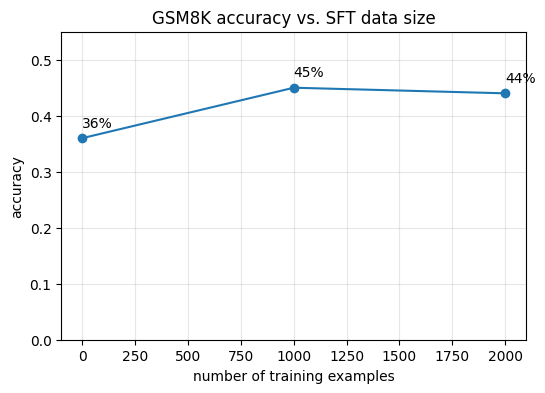

In [ ]:

clear_memory()
sft2_model, sft2_tok = load_math_model(lora_path=adapter_2k)
b7 = evaluate_gsm8k(sft2_model, sft2_tok, gsm8k_test_100,
                    num_samples=100, output_name="b7_lora2k.json")
acc_2k = b7["accuracy"]
print("B.7 (2k) accuracy:", acc_2k)

import matplotlib.pyplot as plt
xs = [0, 1000, 2000]
ys = [0.36, 0.45, acc_2k]
plt.figure(figsize=(6, 4))
plt.plot(xs, ys, marker="o")
for x, y in zip(xs, ys):
    plt.annotate(f"{y:.0%}", (x, y), textcoords="offset points", xytext=(0, 8))
plt.xlabel("number of training examples")
plt.ylabel("accuracy")
plt.title("GSM8K accuracy vs. SFT data size")
plt.ylim(0, max(ys) + 0.1)
plt.grid(True, alpha=0.3)
plt.savefig("/content/drive/MyDrive/m146_outputs/scaling_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## OBSERVATIONS:

Clearly we see an increase between 0 training examples and 1000 which presumably is where most of the learning happens. Increasing to 2000 shows virtually no accuracy increase, which makes sense as the model already has enough to data to learn from. This is a classic example of diminishing returns, where our accuracy increases less and less with more training data.

In [ ]:
import os
from google.colab import drive
if not os.path.ismount('/content/gdrive'):
    drive.mount('/content/gdrive')
target = '/content/gdrive/MyDrive/m146_outputs'
print("contents of", target, ":", os.listdir(target) if os.path.exists(target) else "FOLDER MISSING")

Mounted at /content/gdrive
contents of /content/gdrive/MyDrive/m146_outputs : ['lora_2k', 'scaling_plot.png']


In [ ]:
import os
ADAPTER = "/content/gdrive/MyDrive/m146_outputs/lora_2k/final_adapter"
assert os.path.exists(ADAPTER), f"not found at {ADAPTER}"
print("using adapter:", ADAPTER)
clear_memory("sft_model","sft_tok","sft2_model","sft2_tok","math_model")
base_model, base_tok = load_math_model()
base_eval = evaluate_gsm8k(base_model, base_tok, gsm8k_test_100.select(range(16)), num_samples=16)
wrong = [(i, r) for i, r in enumerate(base_eval["records"]) if not r["correct"]][:3]
FAILURE_IDX  = [i for i, _ in wrong]
base_records = [r for _, r in wrong]
print("failure indices:", FAILURE_IDX)
clear_memory("base_model","base_tok")
sft_model, sft_tok = load_math_model(lora_path=ADAPTER)
sft_records = evaluate_gsm8k(sft_model, sft_tok, gsm8k_test_100.select(FAILURE_IDX),
                             num_samples=len(FAILURE_IDX))["records"]
for k in range(len(FAILURE_IDX)):
    b, s = base_records[k], sft_records[k]
    print("="*90); print(f"FAILURE {k+1} | ground truth {b['ground_truth']}"); print("Q:", b["question"])
    print("-"*90); print(f"BASE -> {b['extracted_answer']} | correct {b['correct']}"); print(b["model_response"][-700:])
    print("-"*90); print(f"SFT  -> {s['extracted_answer']} | correct {s['correct']}"); print(s["model_response"][-700:]); print()

using adapter: /content/gdrive/MyDrive/m146_outputs/lora_2k/final_adapter


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

failure indices: [2, 4, 7]


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

FAILURE 1 | ground truth 70000
Q: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
------------------------------------------------------------------------------------------
BASE -> -27000 | correct False
0
- Amount spent on repairs: $50,000

Total cost = Purchase price + Repair costs
\[ \text{Total cost} = \$80,000 + \$50,000 = \$130,000 \]

### Step 2: New Value After Repairs
The problem states that the repairs increased the value of the house by 150%.

New value = Original value + (Original value * Percentage increase)
\[ \text{New value} = \$80,000 + (\$80,000 \times 0.15) \]
\[ \text{New value} = \$80,000 + \$12,000 = \$92,000 \]

### Step 3: Profit Calculation
Profit = New value - Total cost
\[ \text{Profit} = \$92,000 - \$130,000 = -\$27,000 \]

Since the result is negative, it means Josh incurred a loss rather than making a profit.

Therefore, the

## B.8

While the base model would incur a mix of arithmetic errors and reasoning errors, the SFT model only seems to make reasoning errors. This indicates that the bulk of the model training resulted in the model fixing arithemtic errors, which explains why going from 1000 to 2000 examples didn't result in a higher accuracy; the model still has reasoning errors.

In [ ]:

b7_sft = evaluate_gsm8k(sft_model, sft_tok, gsm8k_test_100, num_samples=100,
                        output_name="/content/gdrive/MyDrive/m146_outputs/b7_lora2k.json")
print("SFT accuracy:", b7_sft["accuracy"])

sft_wrong = [(i, r) for i, r in enumerate(b7_sft["records"]) if not r["correct"]]
print(f"{len(sft_wrong)} SFT failures out of 100")

for k, (i, r) in enumerate(sft_wrong[:6]):
    print("="*90)
    print(f"#{k+1} (test idx {i}) | GT {r['ground_truth']} | model said {r['extracted_answer']}")
    print("Q:", r["question"])
    print(r["model_response"][-500:])
    print()

SFT accuracy: 0.5
50 SFT failures out of 100
#1 (test idx 0) | GT 18 | model said 82
Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
She gets 16*3=<<16*3=48>>48 eggs a day from her ducks.
She eats 3+4=<<3+4=7>>7 eggs herself.
So, Janet has 48-7=<<48-7=41>>41 eggs left over each day.
That means she makes 41*2=$<<41*2=82>>82 at the farmers’ market.

\boxed{82}

#2 (test idx 1) | GT 3 | model said 4
Q: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
It takes 2+1*2 = <<2+1*2=4>>4 bolts of fabric in total.

\boxed{4}

#3 (test idx 2) | GT 70000 | model said 97500
Q: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the h

## B.9:
My previous analysis was innacurate, arithemetics errors persist alongside reasoning errors, though the actual frequency of each remains unknown. Take questions 2 ans 4 from above. Question 2 demonstrates a simple reasoning error, the model multiplies by 2 for no reason. Question 4 showcases the ever present arithmetic error, and displays the model stating 180*3 = 450, an obviously present slip up.

### B.10-B.11 Few-Shot Prompting


In [ ]:

def few_shot_messages_from_train(train_split, indices=(0, 1, 2)):
    messages = []
    for idx in indices:
        ex = train_split[int(idx)]
        reasoning = ex["answer"].split("####")[0].strip()
        final = extract_gt(ex["answer"])
        messages.append({"role": "user", "content": ex["question"]})
        messages.append({"role": "assistant", "content": f"{reasoning}\n\n\\boxed{{{final}}}"})
    return messages

In [ ]:

import os
ADAPTER = "/content/gdrive/MyDrive/m146_outputs/lora_2k/final_adapter"

few_shot_msgs = few_shot_messages_from_train(gsm8k["train"], indices=(0, 1, 2))
print("built", len(few_shot_msgs), "demo messages")

clear_memory("sft_model","sft_tok","sft2_model","sft2_tok")
base_model, base_tok = load_math_model()
smoke = evaluate_gsm8k(base_model, base_tok, gsm8k_test_100.select(range(3)), num_samples=3,
                       few_shot_messages=few_shot_msgs)
print("smoke OK; full run starting...")


base_3shot = evaluate_gsm8k(base_model, base_tok, gsm8k_test_100, num_samples=100,
                            few_shot_messages=few_shot_msgs,
                            output_name="/content/gdrive/MyDrive/m146_outputs/b10_base_3shot.json")
print("base 3-shot accuracy:", base_3shot["accuracy"])

built 6 demo messages


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

smoke OK; full run starting...
base 3-shot accuracy: 0.34


In [ ]:

clear_memory("base_model","base_tok")
sft_model, sft_tok = load_math_model(lora_path=ADAPTER)
sft_3shot = evaluate_gsm8k(sft_model, sft_tok, gsm8k_test_100, num_samples=100,
                           few_shot_messages=few_shot_msgs,
                           output_name="/content/gdrive/MyDrive/m146_outputs/b10_sft2k_3shot.json")
print("SFT-2k 3-shot accuracy:", sft_3shot["accuracy"])

base_0shot = 0.36
sft_0shot  = 0.44
print("\n" + "="*58)
print(f"{'model':<14} {'no-shot':>12} {'3-shot':>12} {'Δ':>12}")
print("-"*58)
print(f"{'base':<14} {base_0shot:>12.2%} {base_3shot['accuracy']:>12.2%} {base_3shot['accuracy']-base_0shot:>+12.2%}")
print(f"{'SFT (2k)':<14} {sft_0shot:>12.2%} {sft_3shot['accuracy']:>12.2%} {sft_3shot['accuracy']-sft_0shot:>+12.2%}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

SFT-2k 3-shot accuracy: 0.53

model               no-shot       3-shot            Δ
----------------------------------------------------------
base                 36.00%       34.00%       -2.00%
SFT (2k)             44.00%       53.00%       +9.00%


## B.11

As we can see, the base model accuracy actually decreased in accuracy after few show prompting, while few shot improved the SFT model accuracy by roughly 9 percent. The base model might perform worse because it's internal weights are not tuned enough to recognize patterns beyond that of the surface level. The deeper intuition and understanding is lacking, which may lead the model to pick up patterns in the demonstration questions that are irreleent, throwing off accuracy. The SFT benifits from few shot prompting significantly more than the base model most likely because the mode is already trained to produce things like boxed solutions, which allows the model to engage with learning the deeper pattersn that actually contribute to solving the problem correctly.